# Many-body Dephasing: Rate vs Mode Number N

**Goal**: Study how dephasing rate γ scales with the number of storage modes N.

## System:
- N storage modes (qubits) with cross-Kerr coupling
- Storage mode 1: tracked (measure fidelity decay)
- Storage modes 2,3,...,N: randomly switching gates applied
- Two protocols: Free evolution vs Hahn Echo sequence

## Cross-Kerr Hamiltonian:
H = Σᵢⱼ χᵢⱼ · nᵢ · nⱼ (i < j)

where nᵢ = aᵢ†aᵢ is the number operator

In [21]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Set random seed for reproducibility
np.random.seed(42)

## 1. Create Operators

In [22]:
def create_operators(N_storage, n_levels=2):
    """
    Create annihilation operators for buffer and N storage modes.
    
    Parameters:
    -----------
    N_storage : int
        Number of storage modes
    n_levels : int
        Number of levels to keep in each mode (default: 2)
    
    Returns:
    --------
    a : Qobj
        Buffer mode annihilation operator
    b_list : list of Qobj
        List of storage mode annihilation operators
    identity_ops : list of Qobj
        Identity operators for each mode
    """
    # Create identity operators for tensor product
    identity_ops = [qt.qeye(n_levels) for _ in range(N_storage + 1)]
    
    # Buffer mode annihilation operator (first position)
    a = qt.tensor([qt.destroy(n_levels)] + identity_ops[1:])
    
    # Storage mode annihilation operators
    b_list = []
    for i in range(N_storage):
        ops = identity_ops.copy()
        ops[i + 1] = qt.destroy(n_levels)  # i+1 because buffer is at position 0
        b_list.append(qt.tensor(ops))
    
    return a, b_list, identity_ops

## 2. Build Hamiltonian

In [23]:
def build_hamiltonian(a, b_list, chi_bi, chi_ij):
    """
    Build the cross-Kerr Hamiltonian.
    
    H = sum_i chi_bi * n_buffer * n_storage_i 
        + sum_{i<j} chi_ij[i,j] * n_storage_i * n_storage_j
    
    where n = a†a is the number operator
    
    Parameters:
    -----------
    a : Qobj
        Buffer mode annihilation operator
    b_list : list of Qobj
        Storage mode annihilation operators
    chi_bi : float
        Cross-Kerr coupling between buffer and storage modes
    chi_ij : float or ndarray
        Cross-Kerr coupling between storage modes
        If float: same coupling for all pairs
        If ndarray: chi_ij[i,j] is the coupling between modes i and j
    
    Returns:
    --------
    H : Qobj
        Total Hamiltonian
    """
    N_storage = len(b_list)
    
    # Number operators
    n_buffer = a.dag() * a
    n_storage = [b.dag() * b for b in b_list]
    
    # Cross-Kerr between buffer and storage modes
    H = sum(chi_bi * n_buffer * n_storage[i] for i in range(N_storage))
    
    # Cross-Kerr between storage modes
    for i in range(N_storage):
        for j in range(i + 1, N_storage):
            # Handle both scalar and array chi_ij
            if np.isscalar(chi_ij):
                chi_value = chi_ij
            else:
                chi_value = chi_ij[i, j]
            H += chi_value * n_storage[i] * n_storage[j]
    
    return H

## 3. Generate Random Bloch States

In [24]:
def random_bloch_state(n_levels=2):
    """
    Generate a random Bloch state by selecting from 6 cardinal states.

    For n_levels=2, randomly selects one of:
    - |0⟩
    - |1⟩
    - |+⟩ = (|0⟩ + |1⟩)/√2
    - |-⟩ = (|0⟩ - |1⟩)/√2
    - |+i⟩ = (|0⟩ + i|1⟩)/√2
    - |-i⟩ = (|0⟩ - i|1⟩)/√2

    Parameters:
    -----------
    n_levels : int
        Number of levels (default: 2 for qubit)

    Returns:
    --------
    state : Qobj
        Random pure state from the 6 cardinal states
    """
    if n_levels == 2:
        # Define the 6 cardinal states on the Bloch sphere
        basis_0 = qt.basis(2, 0)  # |0⟩
        basis_1 = qt.basis(2, 1)  # |1⟩

        # Six cardinal states
        states = [
            basis_0,                                          # |0⟩
            basis_1,                                          # |1⟩
            (basis_0 + basis_1).unit(),                      # |+⟩ = (|0⟩ + |1⟩)/√2
            (basis_0 - basis_1).unit(),                      # |-⟩ = (|0⟩ - |1⟩)/√2
            (basis_0 + 1j * basis_1).unit(),                 # |+i⟩ = (|0⟩ + i|1⟩)/√2
            (basis_0 - 1j * basis_1).unit()                  # |-i⟩ = (|0⟩ - i|1⟩)/√2
        ]

        # Randomly select one of the 6 states
        state = states[np.random.randint(0, 6)]
    else:
        # For higher levels, generate random coefficients
        coeffs = np.random.randn(n_levels) + 1j * np.random.randn(n_levels)
        coeffs = coeffs / np.linalg.norm(coeffs)
        state = sum(coeffs[i] * qt.basis(n_levels, i) for i in range(n_levels))

    return state


def create_initial_state(N_storage, n_levels=2, buffer_state='ground'):
    """
    Create initial state with buffer in specified state and random states in storage modes.

    Parameters:
    -----------
    N_storage : int
        Number of storage modes
    n_levels : int
        Number of levels per mode
    buffer_state : str or Qobj
        Buffer state: 'ground', 'excited', or a Qobj state

    Returns:
    --------
    psi0 : Qobj
        Initial state of the composite system
    storage_states : list of Qobj
        List of individual storage mode states (for fidelity calculation)
    """
    # Buffer state
    if buffer_state == 'ground':
        buf_state = qt.basis(n_levels, 0)
    elif buffer_state == 'excited':
        buf_state = qt.basis(n_levels, 1)
    else:
        buf_state = buffer_state

    # Random states for each storage mode
    storage_states = [random_bloch_state(n_levels) for _ in range(N_storage)]

    # Composite initial state
    psi0 = qt.tensor([buf_state] + storage_states)

    return psi0, storage_states

## 4. Extract Storage State and Calculate Fidelity

In [25]:
def extract_storage_state(psi, storage_index, N_storage):
    """
    Extract the reduced density matrix of a specific storage mode.
    
    Parameters:
    -----------
    psi : Qobj
        State of the composite system
    storage_index : int
        Index of the storage mode (0-indexed)
    N_storage : int
        Total number of storage modes
    
    Returns:
    --------
    rho_storage : Qobj
        Reduced density matrix of the specified storage mode
    """
    # Trace out all modes except the specified storage mode
    # Mode indices: 0 (buffer), 1, 2, ..., N_storage (storage modes)
    # We want to keep mode (storage_index + 1)
    keep_index = storage_index + 1
    
    if psi.isket:
        rho = psi * psi.dag()
    else:
        rho = psi
    
    rho_storage = rho.ptrace(keep_index)
    
    return rho_storage

## 5. Main Simulation Function

In [26]:
def simulate_dephasing(N_storage, chi_bi, chi_ij, t_list, n_trials=10, 
                       n_levels=2, buffer_state='ground', chi_ij_fluctuation=0.0,
                       switch_interval=None):
    """
    Simulate many-body dephasing and calculate average fidelity decay.
    
    Parameters:
    -----------
    N_storage : int
        Number of storage modes
    chi_bi : float
        Cross-Kerr coupling between buffer and storage (in angular frequency units)
    chi_ij : float
        Cross-Kerr coupling between storage modes (mean value)
    t_list : array-like
        Time points for evolution
    n_trials : int
        Number of random initial states to average over
    n_levels : int
        Number of levels per mode
    buffer_state : str or Qobj
        Initial buffer state
    chi_ij_fluctuation : float
        Relative standard deviation of chi_ij fluctuations (default: 0.0)
        E.g., 0.1 means 10% fluctuation
    switch_interval : float or None
        Time interval for randomly applying gates to storage modes 2, 3, ..., N
        If None, no gate switching occurs (default behavior)
        Gates are randomly chosen from {I, X, Y, Z, ±X/2, ±Y/2, ±Z/2}
    
    Returns:
    --------
    t_list : array
        Time points
    avg_fidelity : array
        Average fidelity of storage mode 1 as a function of time
    fidelity_std : array
        Standard deviation of fidelity
    """
    # Create operators
    a, b_list, _ = create_operators(N_storage, n_levels)
    
    # Generate chi_ij matrix with fluctuations
    if chi_ij_fluctuation > 0:
        # Create a matrix of chi_ij values with Gaussian fluctuations
        chi_ij_matrix = np.zeros((N_storage, N_storage))
        for i in range(N_storage):
            for j in range(i + 1, N_storage):
                # Add Gaussian fluctuation (mean=chi_ij, std=chi_ij*fluctuation)
                fluctuation = np.random.normal(0, chi_ij * chi_ij_fluctuation)
                chi_ij_matrix[i, j] = chi_ij + fluctuation
                chi_ij_matrix[j, i] = chi_ij_matrix[i, j]  # Keep symmetric
        chi_ij_value = chi_ij_matrix
    else:
        # Use uniform chi_ij for all pairs
        chi_ij_value = chi_ij
    
    # Build Hamiltonian
    H = build_hamiltonian(a, b_list, chi_bi, chi_ij_value)
    
    # Store fidelities for all trials
    fidelities = np.zeros((n_trials, len(t_list)))
    
    for trial in range(n_trials):
        print(f"Trial {trial + 1}/{n_trials}")
        
        # Create initial state (same for all time points in this trial)
        psi0, storage_states = create_initial_state(N_storage, n_levels, buffer_state)
        
        if switch_interval is None:
            # Standard evolution without switching
            result = qt.mesolve(H, psi0, t_list, [], [])
            
            # Calculate fidelity for storage mode 1 at each time
            for i, t in enumerate(t_list):
                psi_t = result.states[i]
                rho_storage1 = extract_storage_state(psi_t, 0, N_storage)
                fidelities[trial, i] = qt.fidelity(rho_storage1, storage_states[0])**2
        else:
            # Evolution with periodic gate switching
            # For each time point, restart from initial state and evolve with switching
            for i, t_target in enumerate(t_list):
                current_state = psi0  # Start from initial state for each time point
                t_current = 0
                
                # Evolve to t_target with switching every switch_interval
                while t_current < t_target:
                    # Determine next evolution time (either next switch or target)
                    t_next = min(t_current + switch_interval, t_target)
                    dt = t_next - t_current
                    
                    if dt > 0:
                        # Evolve for this segment
                        result_segment = qt.mesolve(H, current_state, [0, dt], [], [])
                        current_state = result_segment.states[-1]
                        t_current = t_next
                    
                    # Apply random gates after each switch_interval (except at final target)
                    if t_current < t_target:
                        current_state = apply_random_gates(current_state, N_storage, n_levels)
                
                # Calculate fidelity at this time point
                rho_storage1 = extract_storage_state(current_state, 0, N_storage)
                fidelities[trial, i] = qt.fidelity(rho_storage1, storage_states[0])**2
    
    # Calculate average and standard deviation
    avg_fidelity = np.mean(fidelities, axis=0)
    fidelity_std = np.std(fidelities, axis=0)
    
    return t_list, avg_fidelity, fidelity_std


def get_random_gate():
    """
    Randomly select a gate from the set {I, X, Y, Z, ±X/2, ±Y/2, ±Z/2}.
    
    Returns:
    --------
    gate : Qobj
        Randomly selected 2x2 unitary gate
    """
    # Define all possible gates
    I = qt.qeye(2)
    X = qt.sigmax()
    Y = qt.sigmay()
    Z = qt.sigmaz()
    
    # Rotation gates (±90° = ±π/2)
    Rx_plus = (-1j * np.pi/4 * X).expm()   # Rx(+π/2)
    Rx_minus = (1j * np.pi/4 * X).expm()   # Rx(-π/2)
    Ry_plus = (-1j * np.pi/4 * Y).expm()   # Ry(+π/2)
    Ry_minus = (1j * np.pi/4 * Y).expm()   # Ry(-π/2)
    Rz_plus = (-1j * np.pi/4 * Z).expm()   # Rz(+π/2)
    Rz_minus = (1j * np.pi/4 * Z).expm()   # Rz(-π/2)
    
    gates = [I, X, Y, Z, Rx_plus, Rx_minus, Ry_plus, Ry_minus, Rz_plus, Rz_minus]
    
    return gates[np.random.randint(0, len(gates))]


def apply_random_gates(psi, N_storage, n_levels=2):
    """
    Apply random gates to storage modes 2, 3, ..., N, keeping storage 1 and buffer unchanged.
    
    Parameters:
    -----------
    psi : Qobj
        Current state of the composite system
    N_storage : int
        Number of storage modes
    n_levels : int
        Number of levels per mode
    
    Returns:
    --------
    new_psi : Qobj
        New state after applying random gates
    """
    current_state = psi
    
    # Apply random gate to each storage mode except storage 1
    # Mode indices: 0 (buffer), 1 (storage 1), 2, 3, ..., N_storage
    for storage_idx in range(1, N_storage):  # storage_idx 1, 2, ..., N_storage-1 correspond to storage modes 2, 3, ..., N
        # Select random gate
        gate = get_random_gate()
        
        # Create full operator: identity on all modes except this storage mode
        # The storage mode is at position (storage_idx + 1) in the tensor product
        # (position 0 is buffer, position 1 is storage 1, position 2 is storage 2, etc.)
        mode_position = storage_idx + 1
        
        # Build tensor product operator
        ops_list = [qt.qeye(n_levels) for _ in range(N_storage + 1)]
        ops_list[mode_position] = gate
        full_gate = qt.tensor(ops_list)
        
        # Apply gate to state
        if current_state.isket:
            current_state = full_gate * current_state
        else:
            current_state = full_gate * current_state * full_gate.dag()
    
    return current_state

## 6. Fitting and Analysis

In [27]:
def exponential_decay(t, A, gamma, offset):
    """Exponential decay function: A * exp(-gamma * t) + offset"""
    return A * np.exp(-gamma * t) + offset


def fit_dephasing_rate(t_list, avg_fidelity, t_fit_max=None):
    """
    Fit fidelity decay to A*exp(-gamma*t) + offset.
    Uses data-driven initial guess and bounds to ensure robust fitting.
    """
    t_list = np.array(t_list)
    avg_fidelity = np.array(avg_fidelity)

    if t_fit_max is not None:
        mask = t_list <= t_fit_max
        t_fit = t_list[mask]
        f_fit = avg_fidelity[mask]
    else:
        t_fit = t_list
        f_fit = avg_fidelity

    # Data-driven initial guess
    A0      = max(f_fit[0] - f_fit[-1], 0.01)   # amplitude ~ drop in fidelity
    offset0 = max(f_fit[-1], 0.0)                # offset ~ final value
    # Estimate gamma from half-amplitude point
    half = f_fit[0] - 0.5 * A0
    idx  = np.argmin(np.abs(f_fit - half))
    t_half = t_fit[idx] if t_fit[idx] > 0 else t_fit[1]
    gamma0  = np.log(2) / t_half

    p0     = [A0, gamma0, offset0]
    bounds = ([0, 1e-8, -0.1], [2, 10, 1.1])   # A, gamma, offset

    try:
        popt, pcov = curve_fit(exponential_decay, t_fit, f_fit,
                               p0=p0, bounds=bounds, maxfev=10000)
        gamma = popt[1]
    except Exception as e:
        print(f"Fitting failed: {e}")
        gamma = np.nan
        popt  = [np.nan, np.nan, np.nan]
        pcov  = None

    return gamma, popt, pcov

## 2-Qubit Verification Test

Simplified test with N=2 to verify the model works correctly.

## Protocol Comparison: Free Evolution vs Hahn Echo

**Free Evolution**: Direct evolution with random gate switching

**Hahn Echo Sequence**:
1. Ry(π/2) → storage 1
2. Evolve T/2 (with switching on other modes)
3. X(π) → storage 1 (echo pulse)
4. Evolve T/2 (with switching)
5. Ry(-π/2) × X(π) → storage 1 (final gates)
6. Measure fidelity

In [8]:
def simulate_two_qubit_echo(chi, t_list, n_trials=10, switch_interval=1.0):
    """
    2-qubit dephasing with Hahn echo sequence.
    
    Sequence:
    1. Apply Ry(π/2) to qubit 1 (|0⟩ → |+y⟩)
    2. Free evolution for T/2 with switching on qubit 2
    3. Apply X(π) to qubit 1 (echo pulse)
    4. Free evolution for T/2 with switching on qubit 2
    5. Apply Ry(-π/2) to qubit 1
    6. Measure fidelity (should return to |0⟩ if no dephasing)
    
    Parameters:
    -----------
    chi : float
        Cross-Kerr coupling strength
    t_list : array-like
        Total evolution times (will be split into T/2 + T/2)
    n_trials : int
        Number of trials to average over
    switch_interval : float
        Time interval for applying random gates to qubit 2
    
    Returns:
    --------
    t_list : array
        Time points
    avg_fidelity : array
        Average fidelity (should be 1.0 if echo works perfectly)
    fidelity_std : array
        Standard deviation
    """
    # Create operators for 2 qubits
    a1 = qt.tensor(qt.destroy(2), qt.qeye(2))
    a2 = qt.tensor(qt.qeye(2), qt.destroy(2))
    
    n1 = a1.dag() * a1
    n2 = a2.dag() * a2
    
    H = chi * n1 * n2
    
    # Define pulses for qubit 1
    X = qt.sigmax()
    Y = qt.sigmay()
    Ry_plus_half = (-1j * np.pi/4 * Y).expm()   # Ry(+π/2)
    Ry_minus_half = (1j * np.pi/4 * Y).expm()   # Ry(-π/2)
    X_pi = X  # π rotation around X
    
    # Full operators (apply to qubit 1 only)
    Ry_plus_half_full = qt.tensor(Ry_plus_half, qt.qeye(2))
    Ry_minus_half_full = qt.tensor(Ry_minus_half, qt.qeye(2))
    X_pi_full = qt.tensor(X_pi, qt.qeye(2))
    
    fidelities = np.zeros((n_trials, len(t_list)))
    
    for trial in range(n_trials):
        print(f"Trial {trial + 1}/{n_trials}")
        
        # Initial state: both qubits start in random states
        q1_initial = random_bloch_state(2)
        q2_initial = random_bloch_state(2)
        psi0 = qt.tensor(q1_initial, q2_initial)
        
        for i, t_total in enumerate(t_list):
            # Start from initial state
            current_state = psi0
            
            # 1. Apply Ry(π/2) to qubit 1
            current_state = Ry_plus_half_full * current_state
            current_state = current_state.unit()  # Normalize after gate
            
            # 2. Evolve for T/2 with switching
            t_half = t_total / 2
            t_current = 0
            while t_current < t_half:
                t_next = min(t_current + switch_interval, t_half)
                dt = t_next - t_current
                
                if dt > 0:
                    result = qt.mesolve(H, current_state, [0, dt], [], [])
                    current_state = result.states[-1]
                    current_state = current_state.unit()  # Normalize after evolution
                    t_current = t_next
                
                if t_current < t_half:
                    gate = get_random_gate()
                    gate_full = qt.tensor(qt.qeye(2), gate)
                    current_state = gate_full * current_state
                    current_state = current_state.unit()  # Normalize after gate
            
            # 3. Apply π pulse (echo) to qubit 1
            current_state = X_pi_full * current_state
            current_state = current_state.unit()  # Normalize after gate
            
            # 4. Evolve for T/2 with switching
            t_current = 0
            while t_current < t_half:
                t_next = min(t_current + switch_interval, t_half)
                dt = t_next - t_current
                
                if dt > 0:
                    result = qt.mesolve(H, current_state, [0, dt], [], [])
                    current_state = result.states[-1]
                    current_state = current_state.unit()  # Normalize after evolution
                    t_current = t_next
                
                if t_current < t_half:
                    gate = get_random_gate()
                    gate_full = qt.tensor(qt.qeye(2), gate)
                    current_state = gate_full * current_state
                    current_state = current_state.unit()  # Normalize after gate
            
            # 5. Apply Ry(-π/2) to qubit 1 (FIXED: removed duplicate X_pi)
            current_state = Ry_minus_half_full * X_pi_full* current_state
            current_state = current_state.unit()  # Normalize after gate
            
            # 6. Measure fidelity
            rho1 = current_state.ptrace(0)
            fidelities[trial, i] = qt.fidelity(rho1, q1_initial)**2
    
    avg_fidelity = np.mean(fidelities, axis=0)
    fidelity_std = np.std(fidelities, axis=0)
    
    return t_list, avg_fidelity, fidelity_std

Running Hahn echo sequence...
chi = 0.06283185307179587, switch_interval = 5.0
n_trials = 50, n_points = 20

--- Free Evolution ---
Free trial 1/50


c:\ProgramData\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


Free trial 2/50
Free trial 3/50
Free trial 4/50
Free trial 5/50
Free trial 6/50
Free trial 7/50
Free trial 8/50
Free trial 9/50
Free trial 10/50
Free trial 11/50
Free trial 12/50
Free trial 13/50
Free trial 14/50
Free trial 15/50
Free trial 16/50
Free trial 17/50
Free trial 18/50
Free trial 19/50
Free trial 20/50
Free trial 21/50
Free trial 22/50
Free trial 23/50
Free trial 24/50
Free trial 25/50
Free trial 26/50
Free trial 27/50
Free trial 28/50
Free trial 29/50
Free trial 30/50
Free trial 31/50
Free trial 32/50
Free trial 33/50
Free trial 34/50
Free trial 35/50
Free trial 36/50
Free trial 37/50
Free trial 38/50
Free trial 39/50
Free trial 40/50
Free trial 41/50
Free trial 42/50
Free trial 43/50
Free trial 44/50
Free trial 45/50
Free trial 46/50
Free trial 47/50
Free trial 48/50
Free trial 49/50
Free trial 50/50

--- Echo Sequence ---
Echo trial 1/50
Echo trial 2/50
Echo trial 3/50
Echo trial 4/50
Echo trial 5/50
Echo trial 6/50
Echo trial 7/50
Echo trial 8/50
Echo trial 9/50
Echo tri

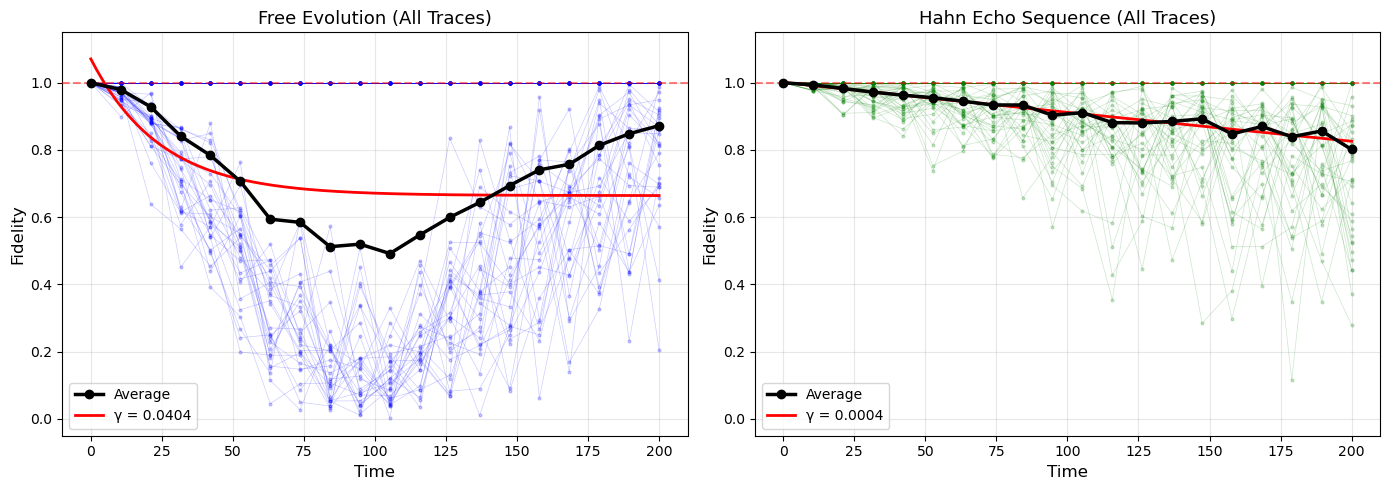


Fidelity Check:
Free evolution - Max: 1.000000, Min: 0.003943
                 F > 1.0: 9 points
Echo sequence  - Max: 1.000000, Min: 0.116065
                 F > 1.0: 0 points


In [14]:
# Run echo sequence - MODIFIED to track all individual fidelities
print("Running Hahn echo sequence...")

# Parameters for this comparison
chi_test = 0.01*np.pi*2  # Cross-Kerr coupling
switch_interval_test = 5.0  # Gate switching interval
t_max_test = 200
n_points_test = 20
t_list_test = np.linspace(0, t_max_test, n_points_test)
n_trials_compare = 50

print(f"chi = {chi_test}, switch_interval = {switch_interval_test}")
print(f"n_trials = {n_trials_compare}, n_points = {n_points_test}")

# === FREE EVOLUTION ===
print("\n--- Free Evolution ---")
a1 = qt.tensor(qt.destroy(2), qt.qeye(2))
a2 = qt.tensor(qt.qeye(2), qt.destroy(2))
n1 = a1.dag() * a1
n2 = a2.dag() * a2
H = chi_test * n1 * n2

all_fid_free = np.zeros((n_trials_compare, len(t_list_test)))

for trial in range(n_trials_compare):
    print(f"Free trial {trial + 1}/{n_trials_compare}")
    q1_initial = random_bloch_state(2)
    q2_initial = random_bloch_state(2)
    psi0 = qt.tensor(q1_initial, q2_initial)
    
    for i, t_target in enumerate(t_list_test):
        current_state = psi0
        t_current = 0
        
        while t_current < t_target:
            t_next = min(t_current + switch_interval_test, t_target)
            dt = t_next - t_current
            
            if dt > 0:
                result = qt.mesolve(H, current_state, [0, dt], [], [])
                current_state = result.states[-1]
                current_state = current_state.unit()
                t_current = t_next
            
            if t_current < t_target:
                gate = get_random_gate()
                gate_full = qt.tensor(qt.qeye(2), gate)
                current_state = gate_full * current_state
                current_state = current_state.unit()
        
        rho1 = current_state.ptrace(0)
        all_fid_free[trial, i] = qt.fidelity(rho1, q1_initial)**2

# === ECHO SEQUENCE ===
print("\n--- Echo Sequence ---")
X = qt.sigmax()
Y = qt.sigmay()
Ry_plus_half = (-1j * np.pi/4 * Y).expm()
Ry_minus_half = (1j * np.pi/4 * Y).expm()
X_pi = X

Ry_plus_half_full = qt.tensor(Ry_plus_half, qt.qeye(2))
Ry_minus_half_full = qt.tensor(Ry_minus_half, qt.qeye(2))
X_pi_full = qt.tensor(X_pi, qt.qeye(2))

all_fid_echo = np.zeros((n_trials_compare, len(t_list_test)))

for trial in range(n_trials_compare):
    print(f"Echo trial {trial + 1}/{n_trials_compare}")
    q1_initial = random_bloch_state(2)
    q2_initial = random_bloch_state(2)
    psi0 = qt.tensor(q1_initial, q2_initial)
    
    for i, t_total in enumerate(t_list_test):
        current_state = psi0
        
        # 1. Ry(π/2)
        current_state = Ry_plus_half_full * current_state
        current_state = current_state.unit()
        
        # 2. Evolve T/2
        t_half = t_total / 2
        t_current = 0
        while t_current < t_half:
            t_next = min(t_current + switch_interval_test, t_half)
            dt = t_next - t_current
            
            if dt > 0:
                result = qt.mesolve(H, current_state, [0, dt], [], [])
                current_state = result.states[-1]
                current_state = current_state.unit()
                t_current = t_next
            
            if t_current < t_half:
                gate = get_random_gate()
                gate_full = qt.tensor(qt.qeye(2), gate)
                current_state = gate_full * current_state
                current_state = current_state.unit()
        
        # 3. X(π) echo
        current_state = X_pi_full * current_state
        current_state = current_state.unit()
        
        # 4. Evolve T/2
        t_current = 0
        while t_current < t_half:
            t_next = min(t_current + switch_interval_test, t_half)
            dt = t_next - t_current
            
            if dt > 0:
                result = qt.mesolve(H, current_state, [0, dt], [], [])
                current_state = result.states[-1]
                current_state = current_state.unit()
                t_current = t_next
            
            if t_current < t_half:
                gate = get_random_gate()
                gate_full = qt.tensor(qt.qeye(2), gate)
                current_state = gate_full * current_state
                current_state = current_state.unit()
        
        # 5. Ry(-π/2) * X(π) - AS USER SPECIFIED
        current_state = Ry_minus_half_full * X_pi_full * current_state
        current_state = current_state.unit()
        
        # 6. Measure
        rho1 = current_state.ptrace(0)
        all_fid_echo[trial, i] = qt.fidelity(rho1, q1_initial)**2

# Calculate averages
fid_test = np.mean(all_fid_free, axis=0)
fid_std_test = np.std(all_fid_free, axis=0)
fid_echo = np.mean(all_fid_echo, axis=0)
fid_std_echo = np.std(all_fid_echo, axis=0)

# Fit
gamma_test, popt_test, _ = fit_dephasing_rate(t_list_test, fid_test)
gamma_echo, popt_echo, _ = fit_dephasing_rate(t_list_test, fid_echo)

print(f"\nFree evolution dephasing rate: γ = {gamma_test:.6f}")
print(f"Echo sequence dephasing rate: γ = {gamma_echo:.6f}")
if gamma_echo > 0 and not np.isnan(gamma_echo):
    print(f"Suppression factor: {gamma_test / gamma_echo:.2f}x")

# Plot comparison with ALL individual traces
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# FREE EVOLUTION - all traces
for i in range(all_fid_free.shape[0]):
    ax1.plot(t_list_test, all_fid_free[i, :], 'o-', alpha=0.2, linewidth=0.5, markersize=2, color='blue')
ax1.plot(t_list_test, fid_test, 'ko-', linewidth=2.5, markersize=6, label='Average', zorder=100)
ax1.axhline(y=1.0, color='r', linestyle='--', linewidth=1.5, alpha=0.5, zorder=99)
if popt_test is not None and not np.isnan(gamma_test):
    t_smooth = np.linspace(t_list_test[0], t_list_test[-1], 200)
    ax1.plot(t_smooth, exponential_decay(t_smooth, *popt_test), 'r-', 
             linewidth=2, label=f'γ = {gamma_test:.4f}', zorder=98)
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('Fidelity', fontsize=12)
ax1.set_title('Free Evolution (All Traces)', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.15)

# ECHO SEQUENCE - all traces
for i in range(all_fid_echo.shape[0]):
    ax2.plot(t_list_test, all_fid_echo[i, :], 'o-', alpha=0.2, linewidth=0.5, markersize=2, color='green')
ax2.plot(t_list_test, fid_echo, 'ko-', linewidth=2.5, markersize=6, label='Average', zorder=100)
ax2.axhline(y=1.0, color='r', linestyle='--', linewidth=1.5, alpha=0.5, zorder=99)
if popt_echo is not None and not np.isnan(gamma_echo):
    t_smooth = np.linspace(t_list_test[0], t_list_test[-1], 200)
    ax2.plot(t_smooth, exponential_decay(t_smooth, *popt_echo), 'r-', 
             linewidth=2, label=f'γ = {gamma_echo:.4f}', zorder=98)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Fidelity', fontsize=12)
ax2.set_title('Hahn Echo Sequence (All Traces)', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.05, 1.15)

plt.tight_layout()
plt.show()

# Check for violations
print(f"\n{'='*70}")
print("Fidelity Check:")
print(f"{'='*70}")
print(f"Free evolution - Max: {np.max(all_fid_free):.6f}, Min: {np.min(all_fid_free):.6f}")
print(f"                 F > 1.0: {np.sum(all_fid_free > 1.0)} points")
print(f"Echo sequence  - Max: {np.max(all_fid_echo):.6f}, Min: {np.min(all_fid_echo):.6f}")
print(f"                 F > 1.0: {np.sum(all_fid_echo > 1.0)} points")
print(f"{'='*70}")

# MAIN ANALYSIS: Dephasing Rate γ vs Number of Qubits N

Simple N-qubit model (same as 2-qubit verification test, extended to N qubits):
- N qubits with cross-Kerr coupling H = Σᵢ<ⱼ χ·nᵢ·nⱼ
- Qubit 1: tracked (measure fidelity decay)
- Qubits 2,3,...,N: random gates applied
- Compare free evolution vs Hahn echo sequence

In [28]:
def run_n_qubit_echo(N, chi, t_list, n_trials, switch_interval):
    """Run Hahn echo sequence for N qubits, tracking qubit 1 fidelity."""
    # Create operators
    a_list = []
    for i in range(N):
        ops = [qt.qeye(2) for _ in range(N)]
        ops[i] = qt.destroy(2)
        a_list.append(qt.tensor(ops))

    # Hamiltonian: H = sum_{i<j} chi * n_i * n_j
    n_list = [a.dag() * a for a in a_list]
    H = sum(chi * n_list[i] * n_list[j] for i in range(N) for j in range(i+1, N))

    # Pulses on qubit 1
    X = qt.sigmax()
    Y = qt.sigmay()
    ops_Ryp = [qt.qeye(2)]*N; ops_Ryp[0] = (-1j*np.pi/4*Y).expm()
    ops_Rym = [qt.qeye(2)]*N; ops_Rym[0] = ( 1j*np.pi/4*Y).expm()
    ops_Xpi = [qt.qeye(2)]*N; ops_Xpi[0] = X
    Ry_plus_half_full  = qt.tensor(ops_Ryp)
    Ry_minus_half_full = qt.tensor(ops_Rym)
    X_pi_full          = qt.tensor(ops_Xpi)

    all_fid = np.zeros((n_trials, len(t_list)))

    for trial in range(n_trials):
        print(f"  Trial {trial+1}/{n_trials}")
        initial_states = [random_bloch_state(2) for _ in range(N)]
        psi0 = qt.tensor(initial_states)
        q1_initial = initial_states[0]

        for i, t_total in enumerate(t_list):
            current_state = psi0

            # 1. Ry(+π/2) on qubit 1
            current_state = (Ry_plus_half_full * current_state).unit()

            # 2. Evolve T/2 with switching
            t_half = t_total / 2
            t_current = 0
            while t_current < t_half:
                t_next = min(t_current + switch_interval, t_half)
                dt = t_next - t_current
                if dt > 0:
                    result = qt.mesolve(H, current_state, [0, dt], [], [])
                    current_state = result.states[-1].unit()
                    t_current = t_next
                if t_current < t_half:
                    for qubit_idx in range(1, N):
                        gate = get_random_gate()
                        ops = [qt.qeye(2) for _ in range(N)]
                        ops[qubit_idx] = gate
                        current_state = (qt.tensor(ops) * current_state).unit()

            # 3. X(π) echo on qubit 1
            current_state = (X_pi_full * current_state).unit()

            # 4. Evolve T/2 with switching
            t_current = 0
            while t_current < t_half:
                t_next = min(t_current + switch_interval, t_half)
                dt = t_next - t_current
                if dt > 0:
                    result = qt.mesolve(H, current_state, [0, dt], [], [])
                    current_state = result.states[-1].unit()
                    t_current = t_next
                if t_current < t_half:
                    for qubit_idx in range(1, N):
                        gate = get_random_gate()
                        ops = [qt.qeye(2) for _ in range(N)]
                        ops[qubit_idx] = gate
                        current_state = (qt.tensor(ops) * current_state).unit()

            # 5. Ry(-π/2) × X(π) on qubit 1
            current_state = (Ry_minus_half_full * X_pi_full * current_state).unit()

            # 6. Measure qubit 1 fidelity
            rho1 = current_state.ptrace(0)
            all_fid[trial, i] = qt.fidelity(rho1, q1_initial)**2

    avg_fid = np.mean(all_fid, axis=0)
    std_fid = np.std(all_fid, axis=0)
    return avg_fid, std_fid, all_fid  # return all traces for plotting

In [29]:
# Parameters (same as 2-qubit verification test)
chi = 0.01 * np.pi * 2   # Cross-Kerr coupling
switch_interval = 5.0    # Gate switching interval
t_list = np.linspace(0, 150, 15)
n_trials = 50
N_range = [2, 3, 4, 5, 6]

print(f"χ = {chi:.4f}, switch_interval = {switch_interval}")
print(f"t_list: 0 to 150, {len(t_list)} points | n_trials = {n_trials} | N = {N_range}")

χ = 0.0628, switch_interval = 5.0
t_list: 0 to 150, 15 points | n_trials = 50 | N = [2, 3, 4, 5, 6]


In [30]:
gamma_echo_vs_N = []
all_fid_vs_N = {}   # store all traces for each N

for N in N_range:
    print(f"\n{'='*60}\nN = {N} qubits\n{'='*60}")
    avg_echo, _, all_fid = run_n_qubit_echo(N, chi, t_list, n_trials, switch_interval)
    gamma_echo, _, _ = fit_dephasing_rate(t_list, avg_echo)
    gamma_echo_vs_N.append(gamma_echo)
    all_fid_vs_N[N] = all_fid
    print(f"  γ_echo = {gamma_echo:.6f}")

print("\nDone!")


N = 2 qubits
  Trial 1/50
  Trial 2/50
  Trial 3/50
  Trial 4/50
  Trial 5/50
  Trial 6/50
  Trial 7/50
  Trial 8/50
  Trial 9/50
  Trial 10/50
  Trial 11/50
  Trial 12/50
  Trial 13/50
  Trial 14/50
  Trial 15/50
  Trial 16/50
  Trial 17/50
  Trial 18/50
  Trial 19/50
  Trial 20/50
  Trial 21/50
  Trial 22/50
  Trial 23/50
  Trial 24/50
  Trial 25/50
  Trial 26/50
  Trial 27/50
  Trial 28/50
  Trial 29/50
  Trial 30/50
  Trial 31/50
  Trial 32/50
  Trial 33/50
  Trial 34/50
  Trial 35/50
  Trial 36/50
  Trial 37/50
  Trial 38/50
  Trial 39/50
  Trial 40/50
  Trial 41/50
  Trial 42/50
  Trial 43/50
  Trial 44/50
  Trial 45/50
  Trial 46/50
  Trial 47/50
  Trial 48/50
  Trial 49/50
  Trial 50/50
  γ_echo = 0.003395

N = 3 qubits
  Trial 1/50
  Trial 2/50
  Trial 3/50
  Trial 4/50
  Trial 5/50
  Trial 6/50
  Trial 7/50
  Trial 8/50
  Trial 9/50
  Trial 10/50
  Trial 11/50
  Trial 12/50
  Trial 13/50
  Trial 14/50
  Trial 15/50
  Trial 16/50
  Trial 17/50
  Trial 18/50
  Trial 19/50
  Tr

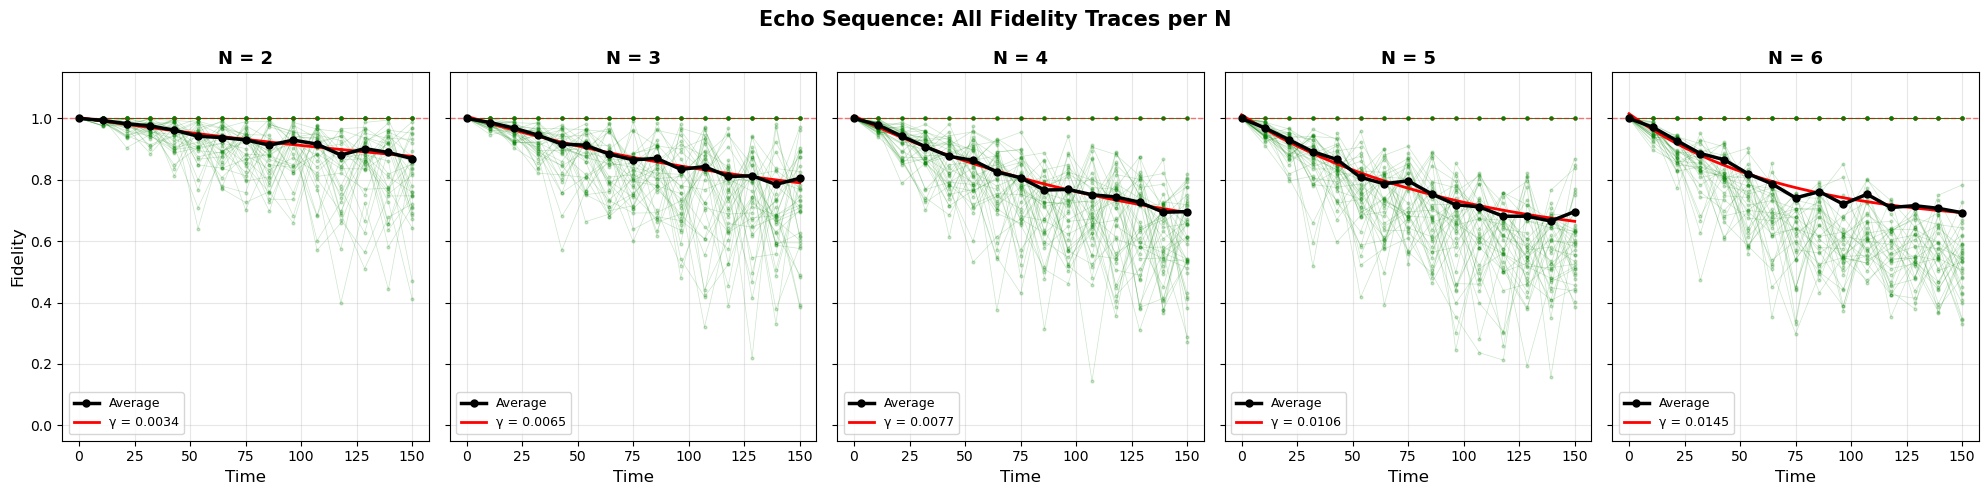

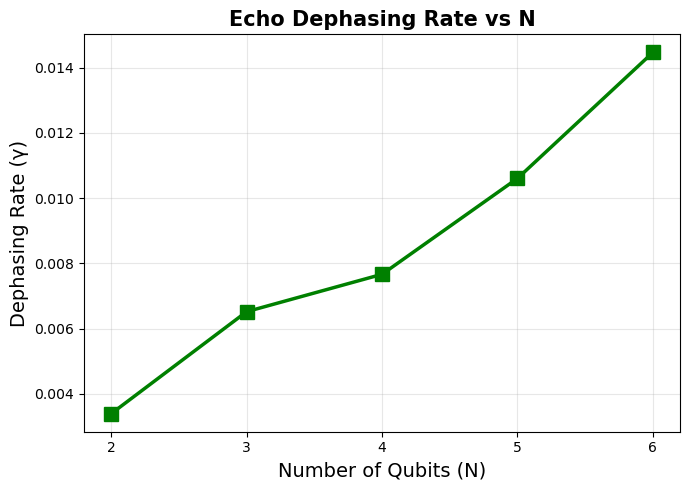


   N         γ_echo
---------------------------------------------
   2       0.003395
   3       0.006520
   4       0.007666
   5       0.010604
   6       0.014464


In [31]:
n_cols = len(N_range)
fig, axes = plt.subplots(1, n_cols, figsize=(4*n_cols, 5), sharey=True)

for ax, N in zip(axes, N_range):
    all_fid = all_fid_vs_N[N]
    avg_fid = np.mean(all_fid, axis=0)
    gamma = gamma_echo_vs_N[N_range.index(N)]

    # All individual traces
    for k in range(all_fid.shape[0]):
        ax.plot(t_list, all_fid[k], 'o-', alpha=0.2, linewidth=0.5, markersize=2, color='green')

    # Average
    ax.plot(t_list, avg_fid, 'ko-', linewidth=2.5, markersize=5, label='Average', zorder=100)

    # Exponential fit
    _, popt, _ = fit_dephasing_rate(t_list, avg_fid)
    if popt is not None and not np.isnan(gamma):
        t_smooth = np.linspace(t_list[0], t_list[-1], 200)
        ax.plot(t_smooth, exponential_decay(t_smooth, *popt), 'r-',
                linewidth=2, label=f'γ = {gamma:.4f}', zorder=99)

    ax.axhline(y=1.0, color='r', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Time', fontsize=12)
    ax.set_title(f'N = {N}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.15)

axes[0].set_ylabel('Fidelity', fontsize=12)
fig.suptitle('Echo Sequence: All Fidelity Traces per N', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# γ vs N summary plot
fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.plot(N_range, gamma_echo_vs_N, 's-', markersize=10, linewidth=2.5, color='green')
ax2.set_xlabel('Number of Qubits (N)', fontsize=14)
ax2.set_ylabel('Dephasing Rate (γ)', fontsize=14)
ax2.set_title('Echo Dephasing Rate vs N', fontsize=15, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(N_range)
plt.tight_layout()
plt.show()

print(f"\n{'='*45}")
print(f"{'N':>4} {'γ_echo':>14}")
print('-'*45)
for i, N in enumerate(N_range):
    print(f"{N:4d} {gamma_echo_vs_N[i]:14.6f}")
print('='*45)